# Model met 3 features

Hier is eerste ontwerp van van het model waarbij we maar 3 features gebruiken, we hebben deze 3 features gekozen:

stm_fh_duur: Dit is onze target variabele, dit is hoelang het duurt voordat de treinen weer rijden.   
stm_prioriteit: Dit is de prioriteitsindicatie, dat zegt hoe belangrijk het is dat deze storing snel opgelost moet worden.   
stm_oorz_code: Dit is de oorzaak code, dat geeft aan wat de oorzaak is van de storing.   
stm_sap_meldtijd: Dit is de meldtijd, dat zegt hoelaat de melding is gemaakt.    

Dit zijn de spreidingsmaten van de target en feature:

stm_fh_duur: continu    
stm_prioriteit: ordinaal   
stm_oorz_code: nominaal   
stm_sap_meldtijd: continu   

Onderzoeksvraag: Kunnen wij met 3 features al een redelijk model maken die kan voorspellen hoelang het duurt voordat de treinen weer rijden. 

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [138]:
df = pd.read_csv("sap_storing_data_hu_project.csv", low_memory=False)

In [139]:
data = df[["stm_fh_duur", "stm_prioriteit", "stm_oorz_code", "stm_sap_meldtijd"]]
data = data.copy()
data

,stm_fh_duur,stm_prioriteit,stm_oorz_code,stm_sap_meldtijd
0,NaN,NaN,NaN,NaN
1,0.0,9.0,133.0,09:00:00
2,51.0,9.0,143.0,12:35:00
3,40.0,9.0,142.0,16:40:00
4,6.0,9.0,142.0,22:30:00
...,...,...,...,...
898521,83.0,5.0,215.0,08:06:00
898522,83.0,2.0,218.0,09:21:00
898523,83.0,2.0,218.0,09:21:00
898524,19.0,2.0,135.0,14:15:17


We zien missende data, deze doen we weg:

In [120]:
data.dropna(inplace=True)
data

,stm_fh_duur,stm_prioriteit,stm_oorz_code,stm_sap_meldtijd
1,0.0,9.0,133.0,09:00:00
2,51.0,9.0,143.0,12:35:00
3,40.0,9.0,142.0,16:40:00
4,6.0,9.0,142.0,22:30:00
5,7.0,9.0,218.0,11:23:00
...,...,...,...,...
898521,83.0,5.0,215.0,08:06:00
898522,83.0,2.0,218.0,09:21:00
898523,83.0,2.0,218.0,09:21:00
898524,19.0,2.0,135.0,14:15:17


Nu is alle missende data weg, nu kunnen we data omzetten zodat het een model in kan.

In [140]:
data = data[data["stm_sap_meldtijd"].apply(lambda x: isinstance(x, str) and len(x) == 8)]

In [141]:
for index, i in data["stm_sap_meldtijd"].items():
    time_lst = i.split(":") 
    time_in_seconds = float(time_lst[0]) * 3600 + float(time_lst[1]) * 60 + float(time_lst[2])
    data.at[index, "stm_sap_meldtijd"] = time_in_seconds

In [143]:
dummies = pd.get_dummies(data['stm_oorz_code'], prefix='Index')
dummies = dummies.astype(int)

data = pd.concat([data, dummies], axis=1)
data

,stm_fh_duur,stm_prioriteit,stm_oorz_code,stm_sap_meldtijd,Index_33.0,Index_48.0,Index_51.0,Index_130.0,Index_131.0,Index_132.0,...,Index_235.0,Index_239.0,Index_240.0,Index_241.0,Index_242.0,Index_250.0,Index_294.0,Index_298.0,Index_299.0,Index_999.0
1,0.0,9.0,133.0,32400.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,51.0,9.0,143.0,45300.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,40.0,9.0,142.0,60000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6.0,9.0,142.0,81000.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,7.0,9.0,218.0,40980.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898521,83.0,5.0,215.0,29160.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
898522,83.0,2.0,218.0,33660.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
898523,83.0,2.0,218.0,33660.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
898524,19.0,2.0,135.0,51317.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Alle data is klaar, nu doen we een analyse

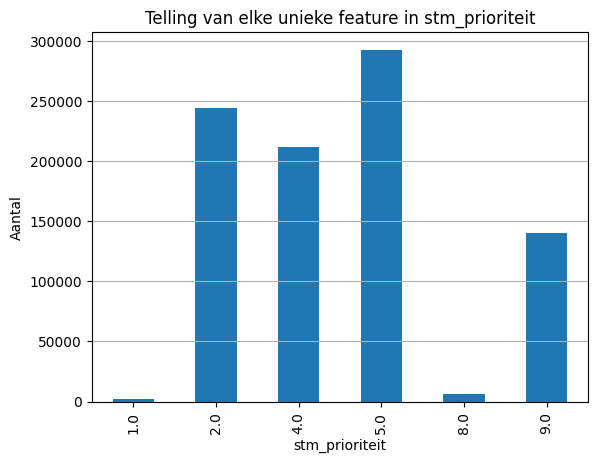

In [168]:
data['stm_prioriteit'].value_counts().sort_index().plot(kind='bar')

plt.title('Telling van elke unieke feature in stm_prioriteit')
plt.xlabel('stm_prioriteit')
plt.ylabel('Aantal')
plt.grid(axis='y')

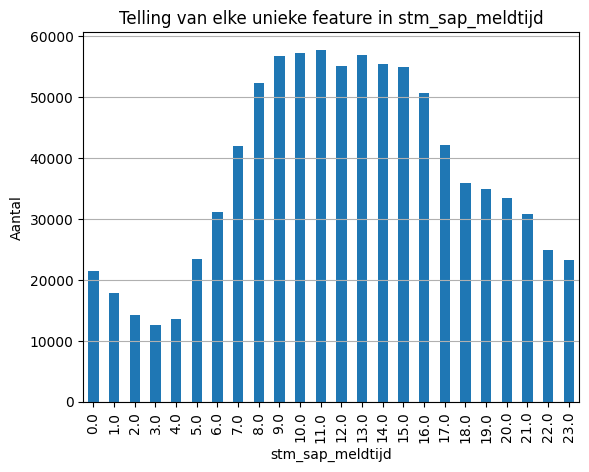

In [167]:
data['stm_sap_meldtijd_in_uren'] = data["stm_sap_meldtijd"] // 3600 # Groeperen per uur

data['stm_sap_meldtijd_in_uren'].value_counts().sort_index().plot(kind='bar')

plt.title('Telling van elke uur in stm_sap_meldtijd')
plt.xlabel('stm_sap_meldtijd')
plt.ylabel('Aantal')
plt.grid(axis='y')

Hier zien we dat de meldtijd zeker invloed heeft, omdat deze in de drukkere tijden van de dag piekt. Dit is logisch omdat er dan ook meer treinen rijden.

Nu de analyse klaar is kunnen we een model gaan maken

In [ ]:
# Om alle kolommen te kopiëren
data.columns


In [ ]:
model = LinearRegression()

x_train, x_test, y_train, y_test = train_test_split(data[['stm_prioriteit', 'stm_oorz_code', 'stm_sap_meldtijd',
       'Index_33.0', 'Index_48.0', 'Index_51.0', 'Index_130.0', 'Index_131.0',
       'Index_132.0', 'Index_133.0', 'Index_134.0', 'Index_135.0',
       'Index_136.0', 'Index_139.0', 'Index_140.0', 'Index_141.0',
       'Index_142.0', 'Index_143.0', 'Index_144.0', 'Index_145.0',
       'Index_146.0', 'Index_147.0', 'Index_148.0', 'Index_149.0',
       'Index_150.0', 'Index_151.0', 'Index_154.0', 'Index_180.0',
       'Index_181.0', 'Index_182.0', 'Index_183.0', 'Index_184.0',
       'Index_185.0', 'Index_186.0', 'Index_187.0', 'Index_188.0',
       'Index_189.0', 'Index_200.0', 'Index_201.0', 'Index_202.0',
       'Index_203.0', 'Index_204.0', 'Index_205.0', 'Index_206.0',
       'Index_207.0', 'Index_208.0', 'Index_209.0', 'Index_210.0',
       'Index_211.0', 'Index_212.0', 'Index_213.0', 'Index_214.0',
       'Index_215.0', 'Index_218.0', 'Index_219.0', 'Index_220.0',
       'Index_221.0', 'Index_222.0', 'Index_223.0', 'Index_224.0',
       'Index_225.0', 'Index_226.0', 'Index_227.0', 'Index_228.0',
       'Index_229.0', 'Index_230.0', 'Index_231.0', 'Index_233.0',
       'Index_234.0', 'Index_235.0', 'Index_239.0', 'Index_240.0',
       'Index_241.0', 'Index_242.0', 'Index_250.0', 'Index_294.0',
       'Index_298.0', 'Index_299.0', 'Index_999.0']], data["stm_fh_duur"], test_size = 0.20, random_state = 10)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

r2_score(y_test, y_pred)

## Conclusie
Het model met 3 features met een r2 score van 0.006358684894837041, is niet goed genoeg om de target te voorspellen.